# MNIST 데이터

In [1]:
import torch
from torchvision.datasets import MNIST
from torchvision import transforms

### 실행 환경에 따라 학습 장치 선택

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## MNIST 훈련셋 준비

In [3]:
DIR_PATH = '../../data'

In [4]:
train_mnist = MNIST(
    root=DIR_PATH,
    train=True,
    transform=None,
    download=True
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:06<00:00, 1446641.44it/s]


Extracting ../../data/MNIST/raw/train-images-idx3-ubyte.gz to ../../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 156643.68it/s]


Extracting ../../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1129458.34it/s]


Extracting ../../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 2911589.30it/s]

Extracting ../../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../../data/MNIST/raw



- 다운로드 시 별도의 변환 객체를 지정하지 않으면 이미지 데이터를 PIL.Image 파일로 불러옴

In [ ]:
# 원본 데이터 확인
type(train_mnist)
# torchvision.datasets.mnist.MNIST
len(train_mnist)
# 60000
train_mnist[0]
# (<PIL.Image.Image image mode=L size=28x28>, 5)

torchvision.datasets.mnist.MNIST

In [17]:
train_mnist.data

type(train_mnist)
# torchvision.datasets.mnist.MNIST
train_mnist.data.shape
# torch.Size([60000, 28, 28])
train_mnist.data.dtype
# torch.uint8

torch.uint8

In [ ]:
img = train_mnist.data[0]

type(img)
# torch.Tensor
img.shape
# torch.Size([28, 28])

## 훈련셋 타겟 확인

In [ ]:
train_mnist.targets
# tensor([5, 0, 4,  ..., 5, 6, 8])
train_mnist.targets[0]
# tensor(5)
train_mnist.classes
# ['0 - zero',
#  '1 - one',
#  '2 - two',
#  '3 - three',
#  '4 - four',
#  '5 - five',
#  '6 - six',
#  '7 - seven',
#  '8 - eight',
#  '9 - nine']
train_mnist.class_to_idx
# {'0 - zero': 0,
#  '1 - one': 1,
#  '2 - two': 2,
#  '3 - three': 3,
#  '4 - four': 4,
#  '5 - five': 5,
#  '6 - six': 6,
#  '7 - seven': 7,
#  '8 - eight': 8,
#  '9 - nine': 9}

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

## 훈련셋 이미지 렌더링

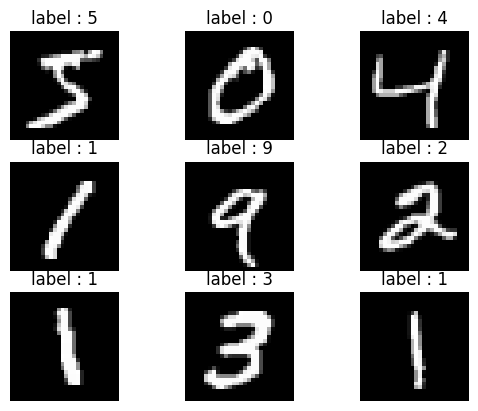

In [ ]:
import matplotlib.pyplot as plt

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = train_mnist.data[i]
    plt.imshow(X=img, cmap='gray')
    plt.title(label=f'label : {train_mnist.targets[i]}')
    plt.axis('off')

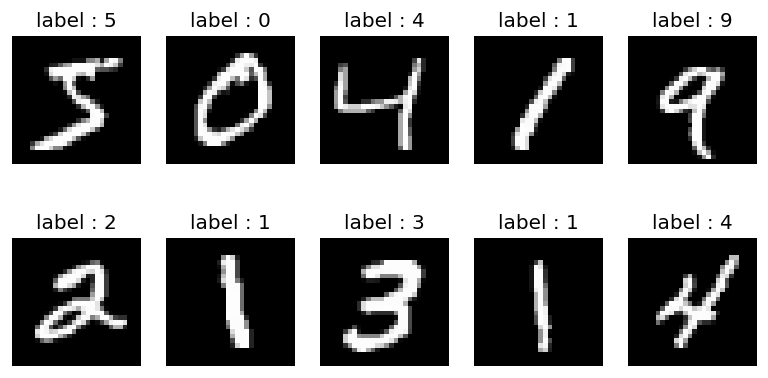

In [28]:
plt.figure(figsize=(8, 4), dpi=120)

for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = train_mnist.data[i]
    plt.imshow(X=img, cmap='gray')
    plt.title(label=f'label : {train_mnist.targets[i]}')
    plt.axis('off')

## 훈련셋 데이터의 전체 평균과 표준편차 계산

In [34]:
pixels = train_mnist.data.float() / 255

In [ ]:
pixels.shape
# torch.Size([60000, 28, 28])

torch.Size([60000, 28, 28])

In [ ]:
pixels.mean() # tensor(0.1307)
pixels.std() # tensor(0.3081)

tensor(0.3081)

## 이미지 변환 객체 생성

In [40]:
mnist_avg = round(pixels.mean().item(), 3)
mnist_std = round(pixels.std().item(), 3)

In [ ]:
# 정규화 포함한 이미지 변환 객체 생성
transform = transforms.Compose(
    transforms=[
        transforms.ToTensor(),
        transforms.Normalize(mean=mnist_avg, std=mnist_std)
    ]
)

## 변환 객체 추가

In [42]:
train_mnist = MNIST(
    root=DIR_PATH,
    train=True,
    transform=transform
)

- 다운로드 시 정규화 및 표준화 변환 객체를 추가하면 이미지 데이터를 실수형 텐서로 불러옴

In [43]:
train_mnist[0]

(tensor([[[-0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253],
          [-0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253],
          [-0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253],
          [-0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253, -0.4253,
           -0.4253, -0.4253, -0.425

## 첫 번째 이미지 확인

In [44]:
img, label = train_mnist[0]

In [ ]:
type(img)
# torch.Tensor
img.shape
# torch.Size([1, 28, 28])

torch.Size([1, 28, 28])

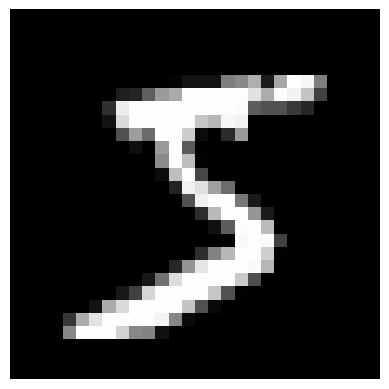

In [51]:
plt.imshow(X=img.squeeze(dim=0), cmap='gray')
plt.axis('off');

## 시험셋 준비

In [52]:
test_mnist = MNIST(
    root=DIR_PATH,
    train=False,
    transform=transform
)

In [ ]:
len(test_mnist)
# 10000

10000

## 외부 파일로 저장

In [54]:
import os
import pandas as pd

In [55]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/dl'

In [56]:
os.chdir('../../data')

In [57]:
pd.to_pickle(
    obj={
        'train_mnist': train_mnist,
        'test_mnist': test_mnist
    },
    filepath_or_buffer='MNIST_Dataset.pkl'
)